In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import SEACells

c:\Users\mikep\miniconda3\envs\Seacells\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
ad = sc.read_h5ad(
    "C:\\Users\\mikep\\Data\\Soybean\\Metacells_approaches\\Pre_metacells_prepped_data\\prepped_data_for_metacells.h5ad"
)

In [3]:
# Number of suggested SEAcells is cells/75
print(len(ad.obs_names) / 75)
n_SEACells = 400

405.32


In [4]:
build_kernel_on = "X_pca"
n_waypoint_eigs = 10

In [5]:
model = SEACells.core.SEACells(
    ad,
    build_kernel_on=build_kernel_on,
    n_SEACells=n_SEACells,
    n_waypoint_eigs=n_waypoint_eigs,
    convergence_epsilon=1e-5,
)

Welcome to SEACells!


In [6]:
model.construct_kernel_matrix()
M = model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/30399 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/30399 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/30399 [00:00<?, ?it/s]

Constructing CSR matrix...


c:\Users\mikep\miniconda3\envs\Seacells\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\mikep\miniconda3\envs\Seacells\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


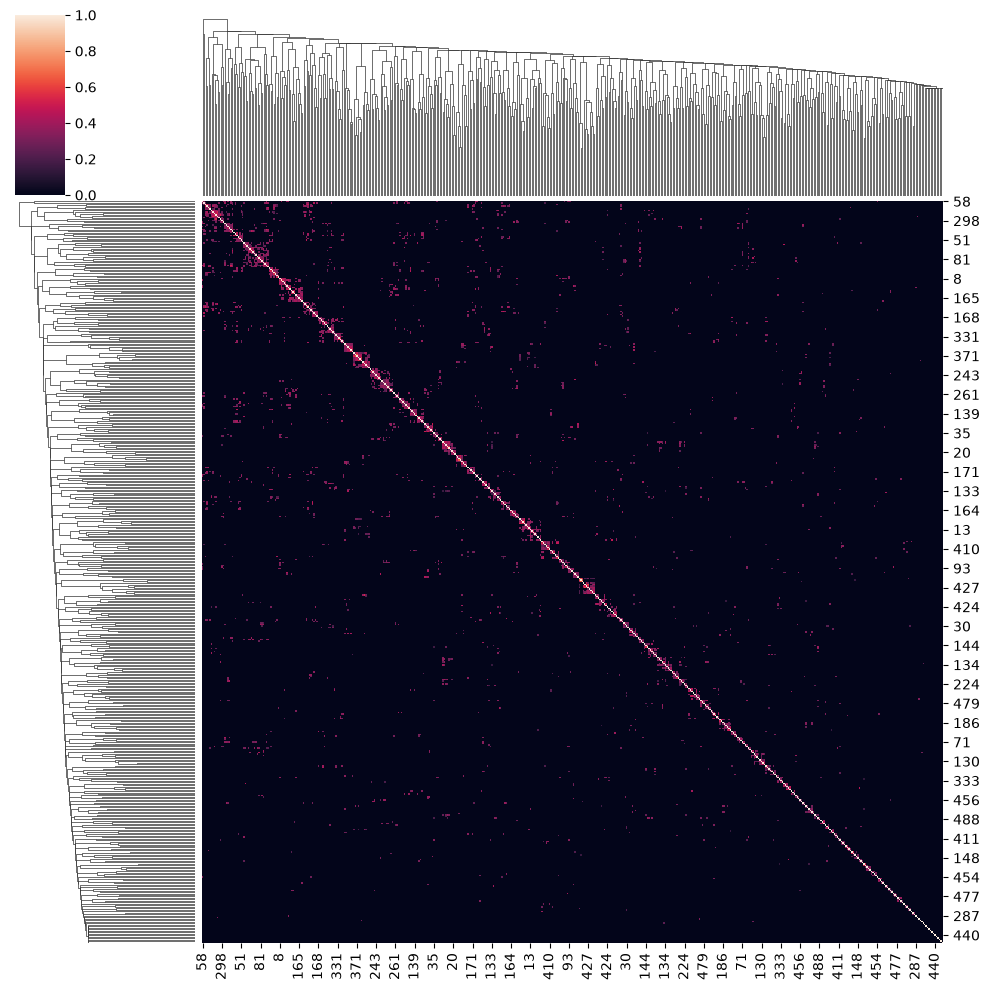

In [7]:
sns.clustermap(M.toarray()[:500, :500])

In [8]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 373 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 37/37 [00:00<00:00, 53.14it/s]

Selecting 27 cells from greedy initialization.


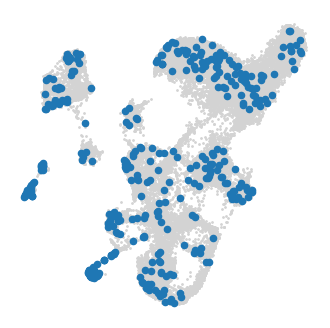

In [ ]:
# SEACells.plot.plot_initialization(ad, model)

In [ ]:
# model.fit(min_iter=10, max_iter=50)

Randomly initialized A matrix.
Setting convergence threshold at 0.00316
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Starting iteration 30.
Completed iteration 30.
Converged after 31 iterations.


In [ ]:
# # You can force the model to run additional iterations step-wise using the .step() function
# print(f'Ran for {len(model.RSS_iters)} iterations')
# for _ in range(5):
#     model.step()
# print(f'Ran for {len(model.RSS_iters)} iterations')

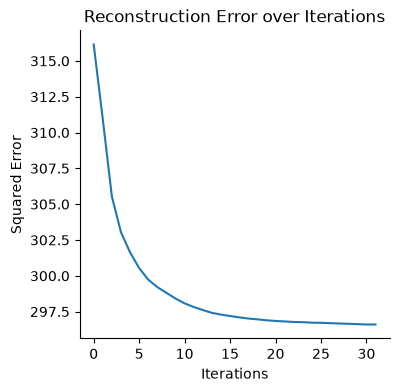

In [ ]:
# model.plot_convergence()

In [ ]:
# ad.write_h5ad(
#     "C:\\Users\\mikep\\Data\\Soybean\\Metacells_approaches\\SEA_cells\\SEA_cells_400_standard_run_object_output.h5ad"
# )

In [15]:
# SEACells 0.3.3 calls sc.AnnData(..., dtype=...), but anndata >= 0.11 removed that
# argument. Redefine the function here so the already-fitted model can be summarized
# without restarting the kernel. (site-packages has also been patched for future runs.)
def _summarize_by_SEACell_fixed(
    adata, SEACells_label="SEACell", celltype_label=None, summarize_layer="raw"
):
    import anndata as _anndata
    from scipy.sparse import csr_matrix
    from tqdm import tqdm

    metacells = adata.obs[SEACells_label].unique()
    summ_matrix = pd.DataFrame(0.0, index=metacells, columns=adata.var_names)

    for m in tqdm(summ_matrix.index):
        cells = adata.obs_names[adata.obs[SEACells_label] == m]
        if summarize_layer == "X":
            summ_matrix.loc[m, :] = np.ravel(adata[cells, :].X.sum(axis=0))
        elif summarize_layer == "raw" and adata.raw is not None:
            summ_matrix.loc[m, :] = np.ravel(adata[cells, :].raw.X.sum(axis=0))
        else:
            summ_matrix.loc[m, :] = np.ravel(
                adata[cells, :].layers[summarize_layer].sum(axis=0)
            )

    counts = csr_matrix(summ_matrix)
    meta_ad = _anndata.AnnData(counts)
    meta_ad.obs_names = summ_matrix.index.astype(str)
    meta_ad.var_names = adata.var_names
    meta_ad.layers["raw"] = counts

    if celltype_label is not None:
        try:
            from SEACells import evaluate

            meta_ad.obs = meta_ad.obs.join(
                evaluate.compute_celltype_purity(adata, celltype_label)
            )
        except Exception as e:
            print(f"Cell type purity failed with Exception {e}")

    return meta_ad


SEACells.core.summarize_by_SEACell = _summarize_by_SEACell_fixed

In [ ]:
# SEACell_ad = SEACells.core.summarize_by_SEACell(
#     ad, SEACells_label="SEACell", summarize_layer="counts"
# )
# SEACell_ad.write_h5ad(
#     "C:\\Users\\mikep\\Data\\Soybean\\Metacells_approaches\\SEA_cells\\SEA_cells_400_standard_run_SEACell_summarized_output.h5ad"
# )

100%|██████████| 400/400 [00:02<00:00, 150.26it/s]


## Metacell co-expression network

Builds a gene-by-gene co-expression network using the 400 SEACell metacells as the
"samples", starting from the saved objects above so the long SEACells fit does not
have to be re-run.

Method follows `build_coexpression_networks.py` (rank-trick Spearman) plus the
methods of **CoCoCoNet** (Lee, Harris & Gillis, *NAR* 2020, 48:W566–W571,
<https://academic.oup.com/nar/article/48/W1/W566/5835815>), which is the reference
used to settle the choices the template script left open:

| Choice | Decision | Source |
| --- | --- | --- |
| Correlation metric | Spearman, computed with the rank/centre/normalise dot-product trick | template + CoCoCoNet ("Spearman's correlation between every pair of genes... non-parametric, so outliers do not dominate") |
| Gene filter | drop genes detected (count > 0) in fewer than **25 %** of metacells (100/400) | specified for this analysis; CoCoCoNet's own filters ("expressed at least once in at least half of the datasets") are dataset-count-based and do not transfer to a single-dataset network |
| Post-processing | adjacency matrix is **rank standardised and divided by the maximum rank**, putting every edge in (0, 1] | CoCoCoNet ("This generates a network that is then rank standardized and normalized by dividing through by the maximum rank") |
| Aggregation across datasets | not applicable — this is a single dataset, so there is nothing to sum before rank standardising | CoCoCoNet aggregates by summing adjacency matrices then re-rank-standardising |
| NA correlations | zero-variance genes are dropped up front (with a single dataset there is nothing to borrow from); any residual NA would be filled with the network median | CoCoCoNet ("We replace these NA values with the median value of the network") |

**One point CoCoCoNet does not specify: library-size normalisation before correlating.**
Their methods go straight from counts to Spearman without stating whether counts were
CPM-normalised. It matters here because SEACell-summed library sizes span 14,404 to
327,549 counts (≈23×) and Spearman ranks each gene *across* metacells, so unnormalised
counts would let the largest metacells sit near the top of nearly every gene's rank
vector. Metacells are therefore **CPM-normalised per metacell** before ranking. No
`log1p` is applied — Spearman is rank-based, so a monotone transform would not change
any edge.

In [17]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as sci
import h5py

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)  # pipeline below is deterministic; set for consistency

SEACELLS_DIR = r"C:\Users\mikep\Data\Soybean\Metacells_approaches\SEA_cells"
FIT_PATH = os.path.join(SEACELLS_DIR, "SEA_cells_400_standard_run_object_output.h5ad")
META_PATH = os.path.join(
    SEACELLS_DIR, "SEA_cells_400_standard_run_SEACell_summarized_output.h5ad"
)
NETWORK_PATH = os.path.join(
    SEACELLS_DIR, "SEA_cells_400_metacell_coexpression_network.h5"
)

MIN_METACELL_FRACTION = 0.25  # keep genes detected in >= 25% of metacells
RANK_CHUNK_ROWS = 500  # rows per chunk when rank standardising the network

# ---------------------------------------------------------------- read objects
# The fitted object is only needed for the metacell size report, so open it backed
# (obs/var load, X stays on disk) to avoid pulling several GB into memory.
ad_fit = sc.read_h5ad(FIT_PATH, backed="r")
seacell_sizes = ad_fit.obs["SEACell"].value_counts()
print(
    f"Fitted object: {ad_fit.n_obs:,} cells x {ad_fit.n_vars:,} genes "
    f"assigned to {seacell_sizes.size} metacells"
)
print(
    f"  cells per metacell: min={seacell_sizes.min()}, median={seacell_sizes.median():.0f}, "
    f"max={seacell_sizes.max()}, mean={seacell_sizes.mean():.1f}"
)
ad_fit.file.close()
del ad_fit

SEACell_ad = sc.read_h5ad(META_PATH)
print(f"Summarized object: {SEACell_ad.n_obs} metacells x {SEACell_ad.n_vars:,} genes")

# Raw SEACell-summed counts (metacells x genes).
counts = SEACell_ad.layers["raw"]
counts = counts.toarray() if sp.issparse(counts) else np.asarray(counts)
counts = counts.astype(np.float64)
gene_names = np.asarray(SEACell_ad.var_names)
n_metacells = counts.shape[0]

# ---------------------------------------------------------------- gene filter
min_metacells = int(np.ceil(MIN_METACELL_FRACTION * n_metacells))
detected_in = (counts > 0).sum(axis=0)
keep = detected_in >= min_metacells
print(
    f"\nGene filter: keeping genes detected in >= {MIN_METACELL_FRACTION:.0%} of "
    f"metacells ({min_metacells}/{n_metacells})"
)
print(
    f"  {int(keep.sum()):,} of {keep.size:,} genes kept "
    f"({int((~keep).sum()):,} dropped)"
)
counts = counts[:, keep]
gene_names = gene_names[keep]

# --------------------------------------------- CPM normalisation per metacell
# See the note above: CoCoCoNet is silent on this, but metacell library sizes vary
# ~23-fold and Spearman ranks each gene across metacells, so we scale them out.
lib_sizes = counts.sum(axis=1)
print(
    f"\nMetacell library sizes: min={lib_sizes.min():,.0f}, "
    f"median={np.median(lib_sizes):,.0f}, max={lib_sizes.max():,.0f}"
)
expr = (counts / lib_sizes[:, None]) * 1e6
del counts

# ------------------------------------------------------- Spearman correlation
# Same rank trick as build_coexpression_networks.py: rank each gene across samples,
# centre, scale to unit length, then the dot product of the rows is Spearman's rho.
expr = expr.T  # genes x metacells, matching the template's row-wise ranking
print(f"\nRanking {expr.shape[0]:,} genes across {expr.shape[1]} metacells ...")
ranks = sci.rankdata(expr, method="average", axis=1)
del expr

# Average ranks always sum to n(n+1)/2, so every gene's mean rank is (n+1)/2 even
# with ties (metacell data has plenty of tied zeros).
ranks -= (n_metacells + 1) / 2.0
norms = np.sqrt(np.square(ranks).sum(axis=1))

# A zero norm means a constant rank vector (no variance) -> correlation undefined.
# CoCoCoNet fills such NAs with the network median, but that only makes sense when
# aggregating over datasets; with a single dataset the gene carries no information,
# so drop it instead.
variable = norms > 0
if not variable.all():
    print(f"  dropping {int((~variable).sum()):,} zero-variance genes")
    ranks = ranks[variable]
    norms = norms[variable]
    gene_names = gene_names[variable]

ranks = (ranks / norms[:, None]).astype(np.float32)
del norms

n_genes = ranks.shape[0]
print(
    f"Computing {n_genes:,} x {n_genes:,} Spearman correlations "
    f"(~{n_genes ** 2 * 4 / 1e9:.2f} GB, float32) ..."
)
network = ranks @ ranks.T
del ranks

# Defensive: with zero-variance genes removed there should be no NAs left, but if any
# survive, fill them with the median network value the way CoCoCoNet does.
n_nan = int(np.isnan(network).sum())
if n_nan:
    median_value = np.nanmedian(network)
    print(
        f"  filling {n_nan:,} NA correlations with the network median "
        f"({median_value:.4f})"
    )
    np.nan_to_num(network, copy=False, nan=median_value)
np.clip(network, -1.0, 1.0, out=network)  # tidy up float error at the extremes

# --------------------------------------------------- CoCoCoNet standardisation
# "rank standardized and normalized by dividing through by the maximum rank".
# Done with a sorted copy plus chunked searchsorted so peak memory stays at roughly
# two copies of the matrix rather than the ~4 copies np.argsort would need.
print("Rank standardising the adjacency matrix ...")
flat = network.reshape(-1)
sorted_values = np.sort(flat)
n_edges = sorted_values.size
# Maximum average rank: ties at the top share the mean of their positions.
top_left = int(np.searchsorted(sorted_values, sorted_values[-1], side="left"))
max_rank = (top_left + n_edges + 1) / 2.0

for start in range(0, n_genes, RANK_CHUNK_ROWS):
    stop = min(start + RANK_CHUNK_ROWS, n_genes)
    block = network[start:stop].reshape(-1)
    lo = np.searchsorted(sorted_values, block, side="left")
    hi = np.searchsorted(sorted_values, block, side="right")
    network[start:stop] = (((lo + hi + 1) / 2.0) / max_rank).reshape(
        stop - start, n_genes
    )
del sorted_values

np.fill_diagonal(network, 1.0)  # keep self-edges at the top of the scale
print(
    f"  edge weights now span {network.min():.6f} to {network.max():.6f} "
    f"(median {np.median(network):.4f})"
)

# ------------------------------------------------------------------- save out
# The template uses DataFrame.to_hdf, but that needs pytables, which is not installed
# in the Seacells env. h5py ships with scanpy/anndata and writes the array without the
# extra in-memory copy pandas would make, so the matrix and its gene labels go out as
# two plain datasets instead. Read it back with the loader defined below.
with h5py.File(NETWORK_PATH, "w") as handle:
    handle.create_dataset("network", data=network, dtype="float32")
    handle.create_dataset(
        "genes", data=gene_names.astype(object), dtype=h5py.string_dtype()
    )
    handle["network"].attrs["metric"] = "spearman"
    handle["network"].attrs["postprocessing"] = "rank standardized / max rank"
    handle["network"].attrs["normalization"] = "CPM per metacell"
    handle["network"].attrs["min_metacell_fraction"] = MIN_METACELL_FRACTION
    handle["network"].attrs["n_metacells"] = n_metacells

print(
    f"\nSaved {n_genes:,} x {n_genes:,} network "
    f"({os.path.getsize(NETWORK_PATH) / 1e9:.2f} GB) to:\n  {NETWORK_PATH}"
)


def load_coexpression_network(path=NETWORK_PATH, genes=None):
    """Read the saved network back. Pass `genes` to pull only those rows/columns,
    which avoids loading the full ~2 GB matrix when you only want a few genes."""
    with h5py.File(path, "r") as handle:
        all_genes = handle["genes"].asstr()[:]
        if genes is None:
            values = handle["network"][:]
            labels = all_genes
        else:
            lookup = {gene: i for i, gene in enumerate(all_genes)}
            missing = [g for g in genes if g not in lookup]
            if missing:
                raise KeyError(f"not in the network: {missing}")
            idx = np.sort([lookup[g] for g in genes])
            values = handle["network"][idx][:, idx]
            labels = all_genes[idx]
    return pd.DataFrame(values, index=labels, columns=labels)


# Preview the top-left corner without materialising a second copy of the matrix.
pd.DataFrame(network[:5, :5], index=gene_names[:5], columns=gene_names[:5])

Fitted object: 30,399 cells x 29,915 genes assigned to 400 metacells
  cells per metacell: min=12, median=72, max=191, mean=76.0
Summarized object: 400 metacells x 29,915 genes

Gene filter: keeping genes detected in >= 25% of metacells (100/400)
  23,277 of 29,915 genes kept (6,638 dropped)

Metacell library sizes: min=13,433, median=67,605, max=323,812

Ranking 23,277 genes across 400 metacells ...
Computing 23,277 x 23,277 Spearman correlations (~2.17 GB, float32) ...
Rank standardising the adjacency matrix ...
  edge weights now span 0.000000 to 1.000000 (median 0.5000)

Saved 23,277 x 23,277 network (2.17 GB) to:
  C:\Users\mikep\Data\Soybean\Metacells_approaches\SEA_cells\SEA_cells_400_metacell_coexpression_network.h5


,Glyma.01G161700.Wm82.a4.v1,Glyma.03G158766.Wm82.a4.v1,Glyma.03G058100.Wm82.a4.v1,Glyma.09G060300.Wm82.a4.v1,Glyma.08G294100.Wm82.a4.v1
Glyma.01G161700.Wm82.a4.v1,1.000000,0.833858,0.577129,0.732906,0.966041
Glyma.03G158766.Wm82.a4.v1,0.833858,1.000000,0.372503,0.946466,0.368041
Glyma.03G058100.Wm82.a4.v1,0.577129,0.372503,1.000000,0.608995,0.264676
Glyma.09G060300.Wm82.a4.v1,0.732906,0.946466,0.608995,1.000000,0.357682
Glyma.08G294100.Wm82.a4.v1,0.966041,0.368041,0.264676,0.357682,1.000000
